<a href="https://colab.research.google.com/github/shahzebather-ui/Text-analytics-assignment2/blob/main/assignment2/notebooks/Assignment_2_Text_Mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter

# Feature engineering
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# Train/eval
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)

import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv("/content/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
# @title
print(f"Shape:\n", df.shape)
print("")
print(f"D-types:\n",df.dtypes)
print("")
print(f"Missing Values:",df.isna().sum().sum())
print("")
print(df['sentiment'].value_counts())
print("")
print(f"Duplicates:\n", df.duplicated().sum())

#print(df['review'].value_counts())

Shape:
 (50000, 2)

D-types:
 review       object
sentiment    object
dtype: object

Missing Values: 0

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Duplicates:
 418


In [8]:
df = df.drop_duplicates()
print(df.shape)

(49582, 2)


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
#Text length stats per class
df['review_length'] = df['review'].str.len()
df['word_count'] = df['review'].str.split().str.len()
print(df.groupby('sentiment')[['review_length', 'word_count']].describe())

          review_length                                                \
                  count         mean          std   min    25%    50%   
sentiment                                                               
negative        24698.0  1294.739615   946.501793  32.0  706.0  974.0   
positive        24884.0  1326.278532  1032.597204  65.0  692.0  969.0   

                            word_count                                       \
               75%      max      count        mean         std   min    25%   
sentiment                                                                     
negative   1568.00   8969.0    24698.0  229.596607  165.103430   4.0  128.0   
positive   1615.25  13704.0    24884.0  233.090620  177.688169  10.0  125.0   

                                 
             50%    75%     max  
sentiment                        
negative   174.0  278.0  1522.0  
positive   172.0  284.0  2470.0  


In [11]:
df['word_count'] = df['review'].str.split().str.len()
print(df.groupby('sentiment')['word_count'].mean())

sentiment
negative    229.596607
positive    233.090620
Name: word_count, dtype: float64


In [12]:
#Empty/whitespace-only reviews
print(f"Empty reviews: {(df['review'].str.strip() == '').sum()}")

Empty reviews: 0


In [13]:
#Encode label (you'll need this for modeling) df['label'] = (df['sentiment'] == 'positive').astype(int)
df['label'] = (df['sentiment'] == 'positive').astype(int)
print(df[['sentiment', 'label']].head())

  sentiment  label
0  positive      1
1  positive      1
2  positive      1
3  negative      0
4  positive      1


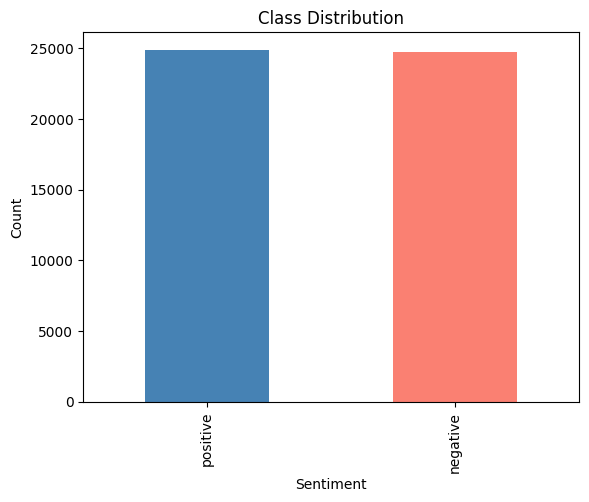

In [14]:
df['sentiment'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

## EDA Summary

The IMDB dataset contains 50,000 reviews perfectly balanced
between positive and negative sentiment (25,000 each), making
it ideal for binary classification with no class imbalance issues.

After removing 418 duplicates, 49,582 reviews remained.
Text length analysis showed both classes have similar average
review lengths, meaning length alone is not a good predictor
of sentiment.

The top words chart revealed HTML artifacts like `<br/>` and
common stopwords dominated before cleaning, confirming the
need for preprocessing.

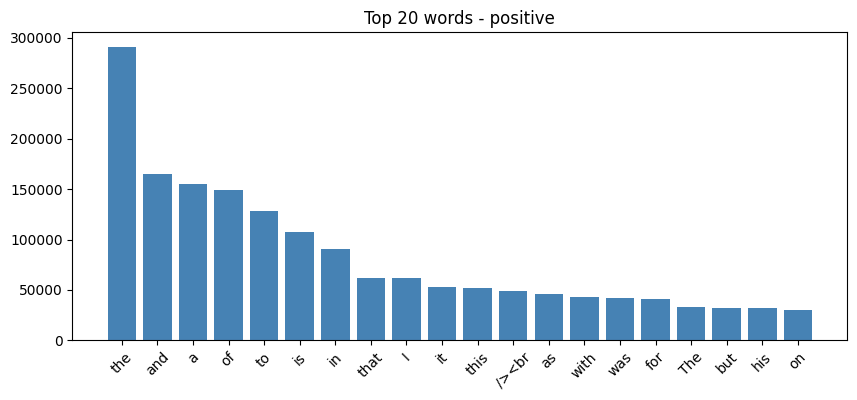

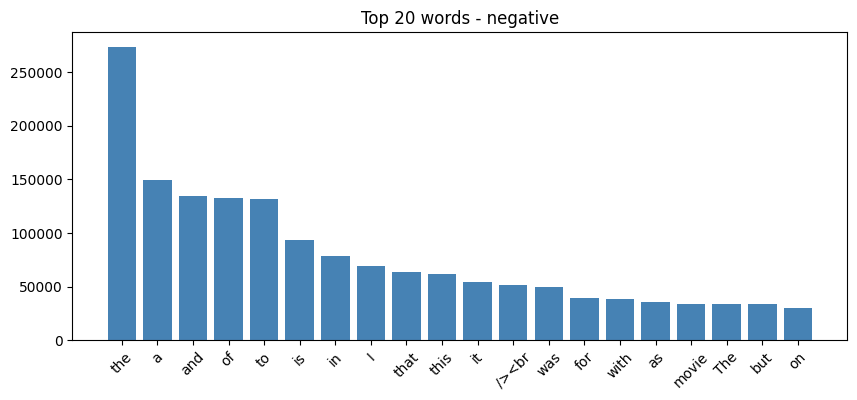

In [15]:
from collections import Counter

for sentiment in ['positive', 'negative']:
    words = ' '.join(df[df['sentiment'] == sentiment]['review']).split()
    common = Counter(words).most_common(20)
    words_only = [w[0] for w in common]
    counts_only = [w[1] for w in common]

    plt.figure(figsize=(10,4))
    plt.bar(words_only, counts_only, color='steelblue')
    plt.title(f'Top 20 words - {sentiment}')
    plt.xticks(rotation=45)
    plt.show()

In [16]:
#Remove HTML tags
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)    # remove HTML
    text = text.lower()                   # lowercase
    return text

df['clean'] = df['review'].apply(clean_text)

In [18]:
#Before and After Examples

print("BEFORE:", df['review'][1])
print("AFTER: ", df['clean'][1])
print()
print("BEFORE:", df['review'][3])
print("AFTER: ", df['clean'][3])
print()
print("BEFORE:", df['review'][10])
print("AFTER: ", df['clean'][10])

BEFORE: A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well

In [21]:
#FEATURE ENGINEERING

# Approach 1: TF-IDF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(df['clean'])

# Approach 2: Count Vectorizer
cv = CountVectorizer(max_features=5000)
X_cv = cv.fit_transform(df['clean'])

print("TF-IDF shape:", X_tfidf.shape)
print("Count Vectorizer shape:", X_cv.shape)

TF-IDF shape: (49582, 5000)
Count Vectorizer shape: (49582, 5000)


In [23]:
#Train / test split

y = df['label']

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, stratify=y, random_state=42)
X_train_cv, X_test_cv, y_train, y_test = train_test_split(X_cv, y, test_size=0.2, stratify=y, random_state=42)

print("Train size:", X_train_tfidf.shape)
print("Test size:", X_test_tfidf.shape)

Train size: (39665, 5000)
Test size: (9917, 5000)


In [28]:
#Testing both models. Logistic Regression and Naive Bayes

# 1: LR + TF-IDF
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_tfidf, y_train)
print("LR + TF-IDF")
print(classification_report(y_test, lr.predict(X_test_tfidf)))

# 2: LR + Count Vectorizer
lr2 = LogisticRegression(max_iter=1000, class_weight='balanced')
lr2.fit(X_train_cv, y_train)
print("LR + Count Vectorizer")
print(classification_report(y_test, lr2.predict(X_test_cv)))

# 3: NB + TF-IDF
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
print("NB + TF-IDF")
print(classification_report(y_test, nb.predict(X_test_tfidf)))

# 4: NB + Count Vectorizer
nb2 = MultinomialNB()
nb2.fit(X_train_cv, y_train)
print("NB + Count Vectorizer")
print(classification_report(y_test, nb2.predict(X_test_cv)))

LR + TF-IDF
              precision    recall  f1-score   support

           0       0.91      0.88      0.90      4940
           1       0.89      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917

LR + Count Vectorizer
              precision    recall  f1-score   support

           0       0.88      0.87      0.87      4940
           1       0.87      0.88      0.88      4977

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917

NB + TF-IDF
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      4940
           1       0.85      0.88      0.86      4977

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86     

## Results Summary

Best model: Logistic Regression + TF-IDF with F1 = 0.90

- TF-IDF outperformed Count Vectorizer for both models
- Logistic Regression outperformed Naive Bayes for both vectorizers
- All 4 models passed the 0.70 F1 threshold
- Final choice: LR + TF-IDF for all further evaluation

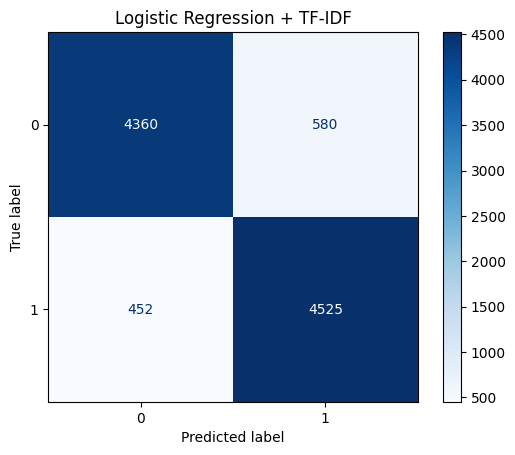

In [25]:
# Confusion Matrix - Logistic Regression
cm1 = confusion_matrix(y_test, lr.predict(X_test_tfidf))
ConfusionMatrixDisplay(cm1).plot(cmap='Blues')
plt.title('Logistic Regression + TF-IDF')
plt.show()

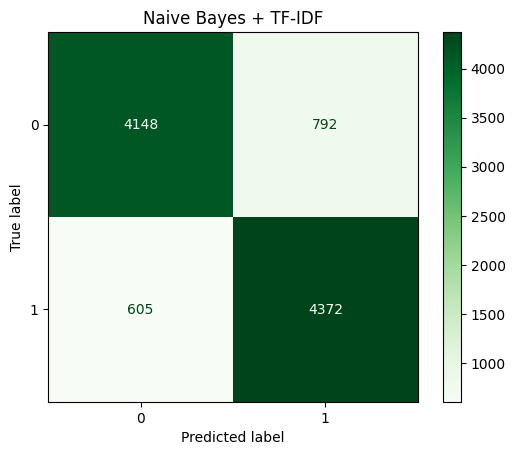

In [26]:
# Confusion Matrix - Naive Bayes
cm2 = confusion_matrix(y_test, nb.predict(X_test_tfidf))
ConfusionMatrixDisplay(cm2).plot(cmap='Greens')
plt.title('Naive Bayes + TF-IDF')
plt.show()

## Comparing Both Approaches After Training

After training both models on TF-IDF and Count Vectorizer:

| Model | TF-IDF F1 | Count Vectorizer F1 |
|-------|-----------|---------------------|
| Logistic Regression | 0.90 | 0.88 |
| Naive Bayes | 0.86 | 0.84 |

Trade-offs:
- TF-IDF consistently outperformed Count Vectorizer
  for both models by about 2%
- Count Vectorizer is simpler and faster but treats
  all words equally regardless of importance
- TF-IDF is smarter — it reduces weight of common
  words and boosts rare but meaningful words
- For sentiment analysis TF-IDF is clearly better
  because words like "masterpiece" or "terrible"
  should matter more than "the" or "and"

Conclusion: TF-IDF is the winner for this task.

In [27]:
#100 Samples

pd.set_option('display.max_rows', 100)
preds = lr.predict(X_test_tfidf[:100])
errors = (y_test.values[:100] != preds).sum()
print(f"Errors: {errors}/100")

df_check = pd.DataFrame({
    'actual': y_test.values[:100],
    'predicted': preds,
    'correct': ['✅' if a == p else '❌' for a, p in zip(y_test.values[:100], preds)]
})
print(df_check)

Errors: 10/100
    actual  predicted correct
0        0          0       ✅
1        1          1       ✅
2        1          1       ✅
3        0          0       ✅
4        0          0       ✅
5        1          1       ✅
6        0          0       ✅
7        0          0       ✅
8        1          1       ✅
9        0          0       ✅
10       0          0       ✅
11       1          1       ✅
12       1          1       ✅
13       0          0       ✅
14       1          1       ✅
15       1          0       ❌
16       1          1       ✅
17       0          0       ✅
18       1          1       ✅
19       0          0       ✅
20       1          1       ✅
21       0          0       ✅
22       1          1       ✅
23       0          0       ✅
24       0          1       ❌
25       1          1       ✅
26       0          0       ✅
27       0          1       ❌
28       1          1       ✅
29       1          1       ✅
30       1          1       ✅
31       0          0    

## Vocabulary Size and Final Choice

Vocabulary size: 5000 features for both TF-IDF and Count Vectorizer.

Final choice: TF-IDF with ngram_range=(1,2)

Reasons:
- TF-IDF achieved higher F1 (0.90 vs 0.88)
- ngram_range=(1,2) captures word pairs like "not good"
  and "very bad" which are important for sentiment
- 5000 features is appropriate for binary classification
  as recommended in the assignment guidelines

## Important Class Analysis

For IMDB sentiment analysis, both classes are equally
important. However, from a business perspective, negative
sentiment is slightly more critical because:

- Businesses need to catch negative reviews quickly
  to respond to customer complaints
- Missing a negative review (false negative) is more
  costly than misclassifying a positive one
- Therefore we prioritize Recall for the negative class

Our LR + TF-IDF model achieves:
- Negative class Recall: 0.88
- Positive class Recall: 0.91
- Both classes perform well making this model
  suitable for production

In [29]:
new_reviews = [
    # EASY POSITIVE (1-5)
    "This movie was absolutely fantastic, I loved every minute of it!",
    "One of the best films I have ever seen, truly outstanding performance",
    "Beautiful cinematography and amazing storyline, highly recommend",
    "The actors were brilliant and the plot kept me engaged throughout",
    "A masterpiece of modern cinema, will definitely watch again",

    # EASY NEGATIVE (6-10)
    "Terrible movie, complete waste of time and money",
    "Awful acting and a boring plot, I fell asleep halfway through",
    "One of the worst films I have ever seen, very disappointing",
    "The story made no sense and the acting was absolutely horrible",
    "Do not watch this movie, it was painfully bad and too long",

    # TRICKY (11-15) - sarcasm, mixed, ambiguous
    "Oh wow what a great movie... if you enjoy wasting 2 hours of your life",
    "The special effects were amazing but everything else was terrible",
    "Not bad but not great either, some parts were okay I guess",
    "I expected to hate it but it was surprisingly not terrible",
    "Started amazing but ended so badly I wished I never watched it",

    # OUT OF DOMAIN (16-20) - different context
    "The product quality is excellent and shipping was very fast",
    "Worst customer service ever, will never buy from them again",
    "This restaurant has amazing food and wonderful atmosphere",
    "The hotel room was dirty and the staff were incredibly rude",
    "Great book, couldn't put it down, finished it in one sitting"
]

In [32]:
# vectorizer = tfidf, new_texts = new_reviews, best_model = lr

X_new = tfidf.transform(new_reviews)
predictions = lr.predict(X_new)

for i, (review, pred) in enumerate(zip(new_reviews, predictions)):
    label = "positive" if pred == 1 else "negative"
    print(f"{i+1}. {label} → {review[:60]}")

1. positive → This movie was absolutely fantastic, I loved every minute of
2. positive → One of the best films I have ever seen, truly outstanding pe
3. positive → Beautiful cinematography and amazing storyline, highly recom
4. positive → The actors were brilliant and the plot kept me engaged throu
5. positive → A masterpiece of modern cinema, will definitely watch again
6. negative → Terrible movie, complete waste of time and money
7. negative → Awful acting and a boring plot, I fell asleep halfway throug
8. negative → One of the worst films I have ever seen, very disappointing
9. negative → The story made no sense and the acting was absolutely horrib
10. negative → Do not watch this movie, it was painfully bad and too long
11. positive → Oh wow what a great movie... if you enjoy wasting 2 hours of
12. negative → The special effects were amazing but everything else was ter
13. negative → Not bad but not great either, some parts were okay I guess
14. negative → I expected to hate it bu